In [ ]:
#para instalar un programa hay que poner el ! Si queremos que el codigo se ejecute en phyton no se pone con exclamación.
#en las holas de Jupiter la ! instala el programa en el ordenador
#los datos normalmente suelen estar en tablas. Hay encabezados que definen que es cada variable. Va a haber v dependientes e independientes que va a haber que identificar. Las instances son las filas.
!pip install ucimlrepo


In [ ]:
from ucimlrepo import fetch_ucirepo
#panda es una librería que nos permite trabajar y hacer cosas con tablas. x va a guardar las características todas menos bebida y te da lo de la bebida. Los metadatos es de donde sale la información.

# fetch dataset
liver_disorders = fetch_ucirepo(id=60)

# data (as pandas dataframes)
X = liver_disorders.data.features
y = liver_disorders.data.targets

# metadata (es solo la primera línea)
print(liver_disorders.metadata)

# variable information
print(liver_disorders.variables)


{'uci_id': 60, 'name': 'Liver Disorders', 'repository_url': 'https://archive.ics.uci.edu/dataset/60/liver+disorders', 'data_url': 'https://archive.ics.uci.edu/static/public/60/data.csv', 'abstract': 'BUPA Medical Research Ltd. database donated by Richard S. Forsyth', 'area': 'Health and Medicine', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 345, 'num_features': 5, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['drinks'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2016, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C54G67', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'The first 5 variables are all blood tests which are thought to be sensitive to liver disorders that might arise from excessive alcohol consumption. Each line in the dataset constitutes the record of a single male individual.\n\nImportant note: The 7

In [ ]:
import pandas as pd #para hacer tablas
import matplotlib.pyplot as plt #para gráficas
import seaborn as sns #correlaciones y procesamiento de datos


In [ ]:
X.head() #para hacer encabezados

,mcv,alkphos,sgpt,sgot,gammagt
0,85,92,45,27,31
1,85,64,59,32,23
2,86,54,33,16,54
3,91,78,34,24,36
4,87,70,12,28,10


In [ ]:
y.head()

,drinks
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
#hacer la cola, ver parte de abajo:
#son 345 instancias pero el 1º numero es el 0
X.tail()

,mcv,alkphos,sgpt,sgot,gammagt
340,99,75,26,24,41
341,96,69,53,43,203
342,98,77,55,35,89
343,91,68,27,26,14
344,98,99,57,45,65


In [ ]:
#ver toda la tabla
print(X)

     mcv  alkphos  sgpt  sgot  gammagt
0     85       92    45    27       31
1     85       64    59    32       23
2     86       54    33    16       54
3     91       78    34    24       36
4     87       70    12    28       10
..   ...      ...   ...   ...      ...
340   99       75    26    24       41
341   96       69    53    43      203
342   98       77    55    35       89
343   91       68    27    26       14
344   98       99    57    45       65

[345 rows x 5 columns]


In [ ]:
#juntar la x con la y: para poder elegir donde queremos meter la información hay que usar un modulo de pandas:
import pandas as pd
xy = pd.concat([X, y], axis=1) #tienes una variable xy, está diciendo que llame a otro dataset que concatene el data set x y en axis 1(que lo ponga como columna). Si fuera axis 0 es para filas
xy.head()

,mcv,alkphos,sgpt,sgot,gammagt,drinks
0,85,92,45,27,31,0.0
1,85,64,59,32,23,0.0
2,86,54,33,16,54,0.0
3,91,78,34,24,36,0.0
4,87,70,12,28,10,0.0


In [ ]:
#ver si hay datos nulos o faltantes
xy.isnull().sum() #isnull transforma xy en conectores bulianos. si hay dato pone true y si no lo hay false. la sum va a sumar todos los valores que no están

,0
mcv,0
alkphos,0
sgpt,0
sgot,0
gammagt,0
drinks,0


In [ ]:
#si hay que rellenar valores
xy.fillna(0, inplace=True) #rellena aquellos datos que falten. Hace la media de cada columna y le da un valor promedio
xy.fillna(xy.mean(), inplace=True)
#otro método: con la mediana, moda, minimo, maximos... interpolaciones

In [ ]:
#metricas del dataset. descripciones estadísticas básicas
xy.describe()

,mcv,alkphos,sgpt,sgot,gammagt,drinks
count,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000
mean,90.159420,69.869565,30.405797,24.643478,38.284058,3.455072
std,4.448096,18.347670,19.512309,10.064494,39.254616,3.337835
min,65.000000,23.000000,4.000000,5.000000,5.000000,0.000000
25%,87.000000,57.000000,19.000000,19.000000,15.000000,0.500000
50%,90.000000,67.000000,26.000000,23.000000,25.000000,3.000000
75%,93.000000,80.000000,34.000000,27.000000,46.000000,6.000000
max,103.000000,138.000000,155.000000,82.000000,297.000000,20.000000


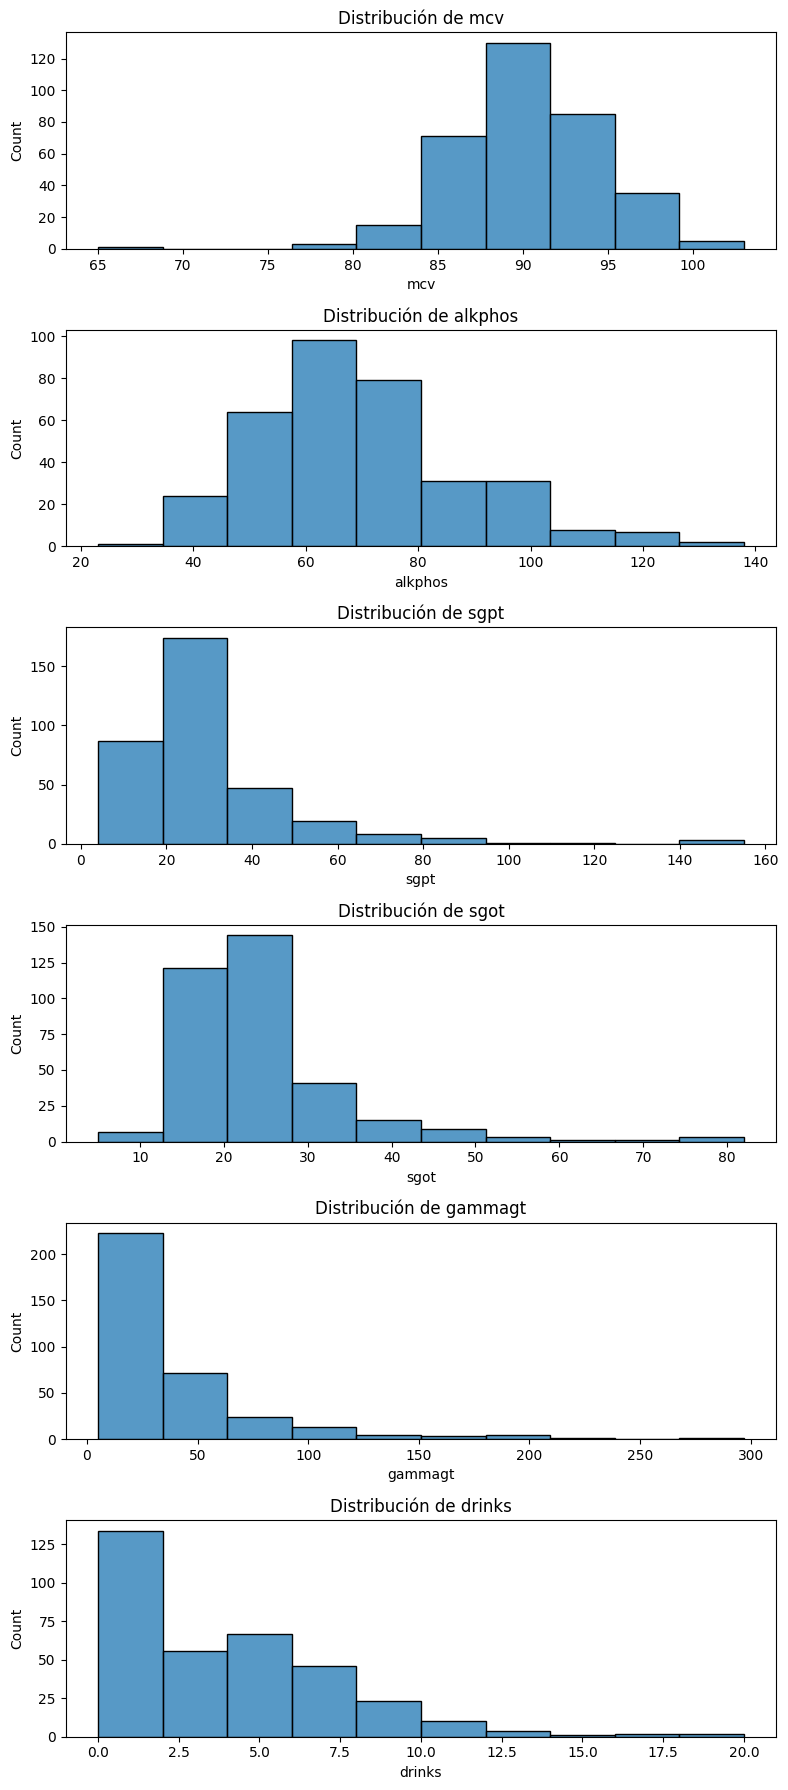

In [ ]:
#crear histogramas para anlizar la distribución de los datos, ver si es normal o no. Ver si crece de manera lineal, exponencial, gausiana, logarítmica
import numpy as np
#lista de variables continuas
continuous_cols= xy.select_dtypes(include=np.number).columns.tolist()
#crear histogramas. Se hace un bucle para generar el histograma de cada variable
fig, axes = plt.subplots(len(continuous_cols), 1, figsize=(8, len(continuous_cols)*3))
for i, col in enumerate(continuous_cols):
  sns.histplot(xy[col], bins=10, kde=False, ax=axes[i])
  axes[i].set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()


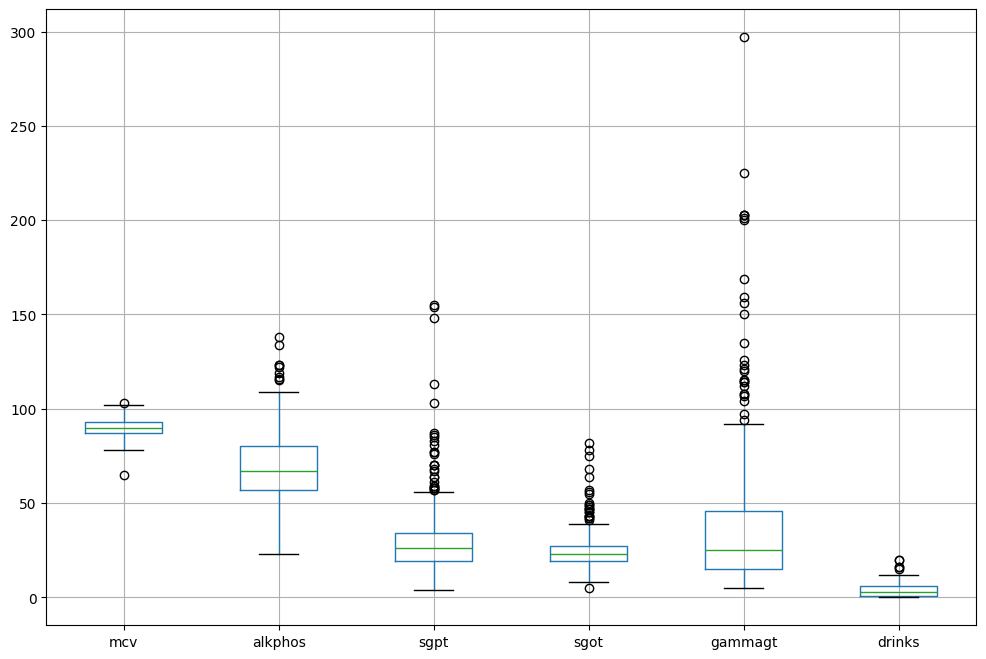

In [ ]:
# Hay que ver si todos los datos entran dentro de la dispersión. Ver si hay valores fuera de rango con un boxplot
xy.boxplot(figsize=(12,8)) #coordenadas x=12 y=8
plt.show()
# línea verde es la mediana, la parte de la caja es el Q1-Q3, el error son las barras y los puntos son los outliers, se sale de lo que es esperable. Tenemos que quiraelos

In [ ]:
xy_df=xy.copy()
#comos e van a eliminar datos generamos una copia
for col in xy.columns:
  Q1= xy_df[col].quantile(0.25) #LE DECIMOS QUE es q1 con la función quantile
  Q3= xy_df[col].quantile(0.75)
  IQR= Q3-Q1 #son mis valores, nos estamos quedando con Q2 al hacer el rango intercuartílico.
  #para eliminar los outliers: formula estadística, se tiene que quitar el último valor. el 1.5 es una constante, se ha determinado que elimina bien los datos.
  lower= Q1-1.5*IQR
  upper= Q3+1.5*IQR
  #filtrar solo los valores dentro de rango
  #en el nuevo data set se recorre cada columna y se elimina el valor más pequeño y se quitan los valores que no estén en rango
  xy_df= xy_df[(xy_df[col] >= lower) & (xy_df[col] <= upper)]

print(xy_df.tail())

     mcv  alkphos  sgpt  sgot  gammagt  drinks
326   93       70    46    30       33     8.0
327   87       55    36    19       25     8.0
329   82       55    18    23       44     8.0
331   97       80    17    20       53     8.0
332  100       83    25    24       28     8.0


In [ ]:
print(xy.tail())

     mcv  alkphos  sgpt  sgot  gammagt  drinks
340   99       75    26    24       41    12.0
341   96       69    53    43      203    12.0
342   98       77    55    35       89    15.0
343   91       68    27    26       14    16.0
344   98       99    57    45       65    20.0


In [ ]:
#tenemos un data set y otro con los eliminados. juntamos los datasets y lo que no esté duplicado es lo que hemos eliminado así que nos lo va a imprimir
#nos enseña las variables eliminadas
eliminados= pd.concat([xy, xy_df]).drop_duplicates(keep=False)
print(eliminados)

     mcv  alkphos  sgpt  sgot  gammagt  drinks
1     85       64    59    32       23     0.0
12    90       64    61    32       13     0.5
19    94      116    11    33       11     0.5
24    84       80    47    33       97     0.5
35    91       72   155    68       82     0.5
..   ...      ...   ...   ...      ...     ...
340   99       75    26    24       41    12.0
341   96       69    53    43      203    12.0
342   98       77    55    35       89    15.0
343   91       68    27    26       14    16.0
344   98       99    57    45       65    20.0

[81 rows x 6 columns]


In [ ]:
xy_df.describe()
#quita la fila entera de cada outlier para que no se queden valores nulos. Se quita el paciente entero.

,mcv,alkphos,sgpt,sgot,gammagt,drinks
count,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000
mean,89.825758,67.276515,24.590909,21.424242,24.939394,2.678030
std,4.007590,16.479139,8.690237,5.131905,14.177451,2.359458
min,78.000000,23.000000,4.000000,8.000000,5.000000,0.000000
25%,87.000000,56.000000,18.000000,18.000000,14.000000,0.500000
50%,90.000000,65.000000,24.000000,21.000000,21.000000,2.000000
75%,92.000000,77.250000,30.000000,25.000000,32.250000,4.000000
max,101.000000,109.000000,52.000000,37.000000,70.000000,8.000000


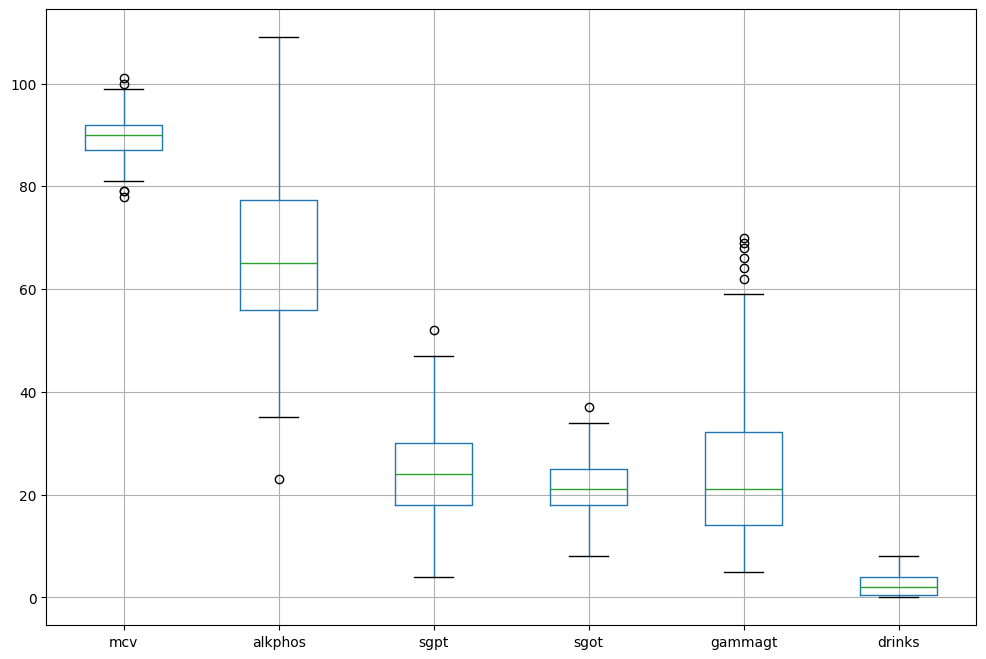

In [ ]:
xy_df.boxplot(figsize=(12,8))
plt.show()

In [ ]:
xy_df2=xy_df.copy()
#generamos otra copia para eliminar el resto de outliers
for col in xy_df.columns:
  Q1= xy_df2[col].quantile(0.25)
  Q3= xy_df2[col].quantile(0.75)
  IQR= Q3-Q1
  lower= Q1-1.5*IQR
  upper= Q3+1.5*IQR
  xy_df2= xy_df2[(xy_df2[col] >= lower) & (xy_df2[col] <= upper)]
print(xy_df2.tail())

     mcv  alkphos  sgpt  sgot  gammagt  drinks
324   91       57    33    23       12     8.0
326   93       70    46    30       33     8.0
327   87       55    36    19       25     8.0
329   82       55    18    23       44     8.0
331   97       80    17    20       53     8.0


In [ ]:
#descripción
xy_df2.describe()

,mcv,alkphos,sgpt,sgot,gammagt,drinks
count,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000
mean,89.862903,66.669355,24.387097,21.298387,23.895161,2.635081
std,3.693379,15.500932,8.586978,5.095811,12.883042,2.333721
min,81.000000,35.000000,4.000000,8.000000,5.000000,0.000000
25%,87.000000,56.000000,18.000000,18.000000,14.000000,0.500000
50%,90.000000,65.000000,24.000000,21.000000,20.000000,2.000000
75%,92.000000,76.250000,29.000000,25.000000,31.000000,4.000000
max,99.000000,107.000000,47.000000,34.000000,59.000000,8.000000


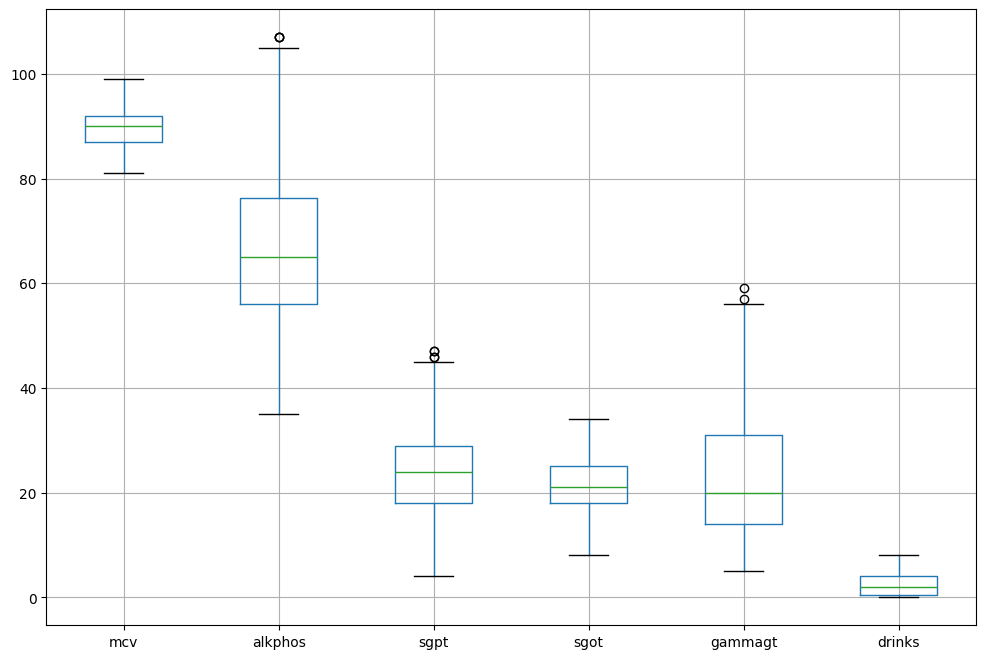

In [ ]:
xy_df2.boxplot(figsize=(12,8))
plt.show()

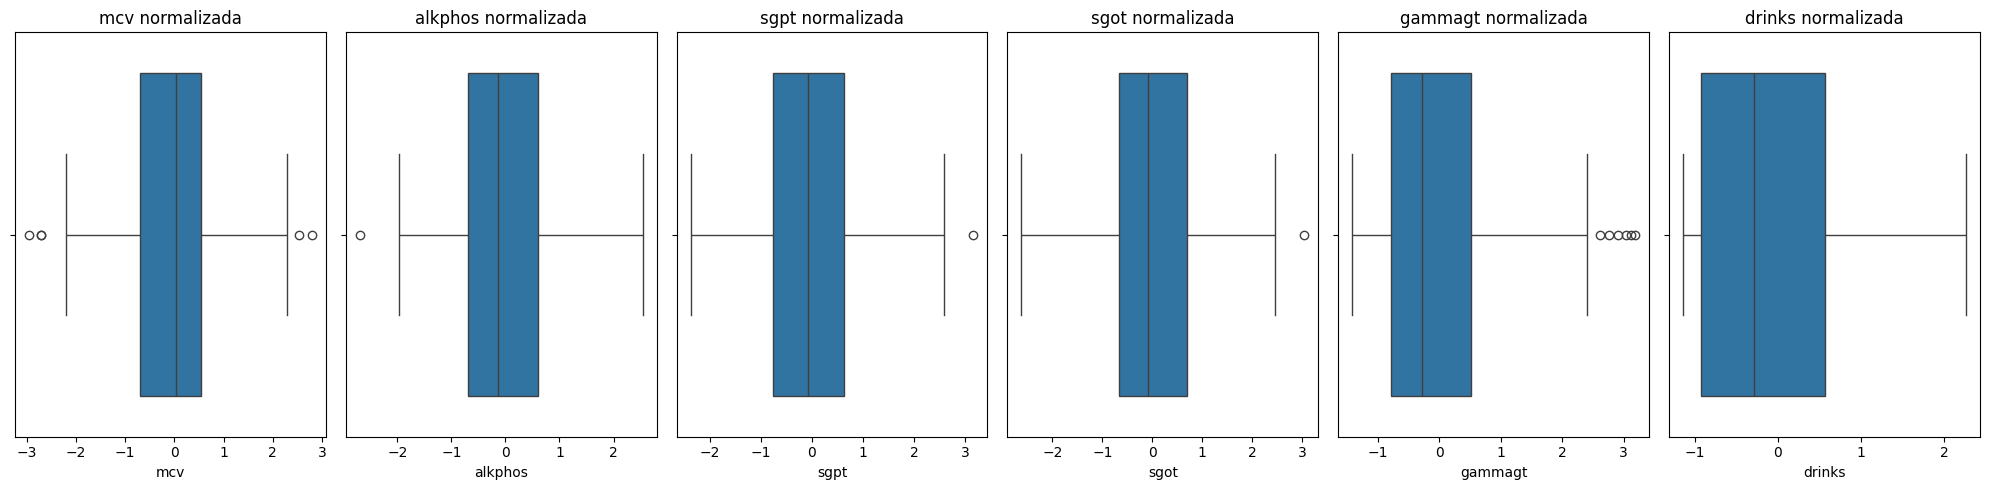

In [ ]:
#normalizar las variables antes del análisis: para poder comparar las cosas
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#detectar columnas numéricas automáticamente
numeric_cols= xy_df.select_dtypes(include=np.number).columns

#crear copia para normalización
xy_scaled=xy_df.copy()

#aplicar normalización Z-score solo sobre las columnas numéricas. Z-score es el standar scale, es aplicar una formula a tus datos
scaler= StandardScaler()
xy_scaled[numeric_cols]= scaler.fit_transform(xy_scaled[numeric_cols])

#Boxplots despues de normalización:
fig, axes=plt.subplots(1, len(numeric_cols), figsize=(20,5))
for i, col in enumerate(numeric_cols):
  sns.boxplot(x=xy_scaled[col], ax=axes[i])
  axes[i].set_title(f"{col} normalizada")
plt.tight_layout()
plt.show()


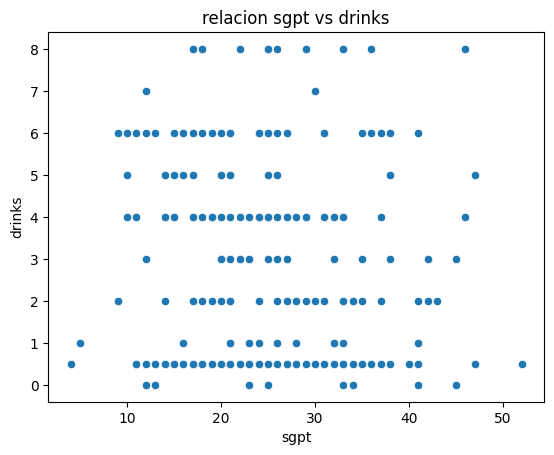

In [ ]:
#relación entre datos:
#relaciones entre variables (sactter plots) correlación por dispersión
#ejemplo: mcv vs drinks (cambiar por cualquier columna numérica si se desea)
if "sgpt" in numeric_cols and "drinks" in numeric_cols:
  sns.scatterplot(x="sgpt", y="drinks", data=xy_df)
  plt.title("relacion sgpt vs drinks")
  plt.show()
else:
  print("no se encontraron columnas 'mcv' y 'drinks' en el dataset")
#nosotros esperamos que la ingesta de alcohol afecte al hígado, pero estas enzimas no están dañadas


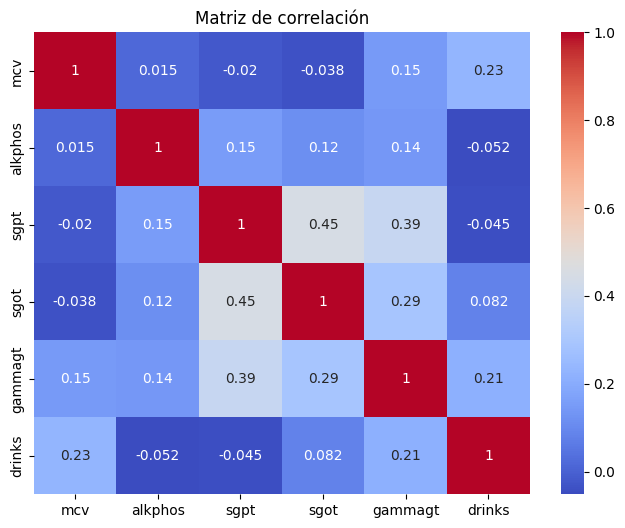

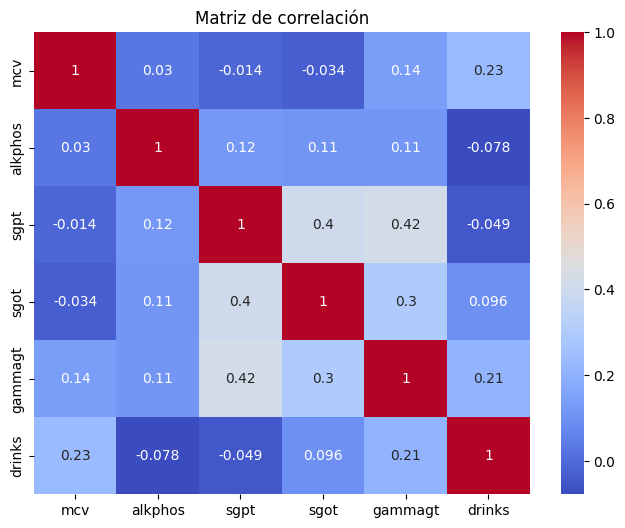

In [ ]:
#de la correlación lineal sacamos otras correlaciones diferentes
#podemos correlacionar datos aplicando matrices de correlación:
#Matriz de correlación:
corr= xy_df[numeric_cols].corr() #para variables continuas o numericas se le aplica una correlación. Te lo hace con pearson
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
#un heatmap por color te correlaciona las variables que conecten mejor (del azul al rojo)
plt.title("Matriz de correlación")
plt.show()
#1 es la correlación perfecta

corr= xy_df[numeric_cols].corr("spearman")
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

Varianza explicada por cada componente principal
PC1:  0.3084
PC2:  0.2156
PC3:  0.1590
PC4:  0.1278
PC5:  0.1090
PC6:  0.0801


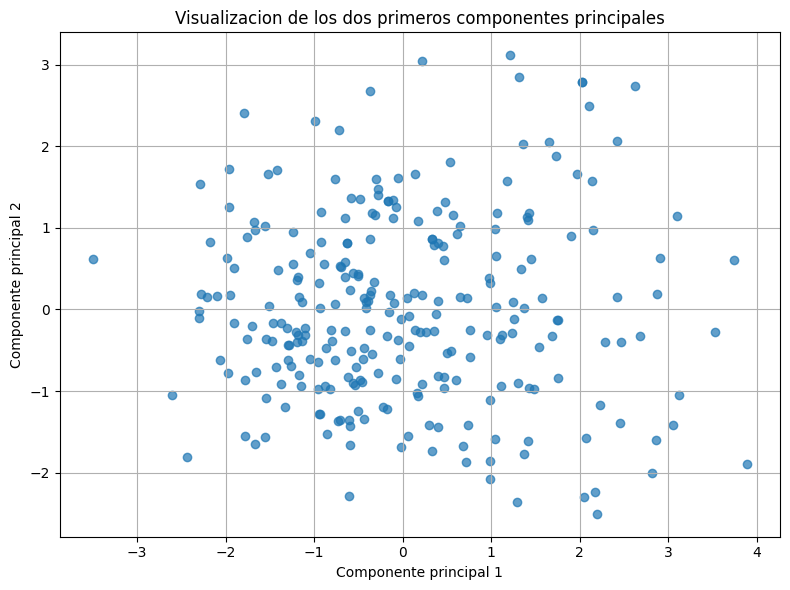

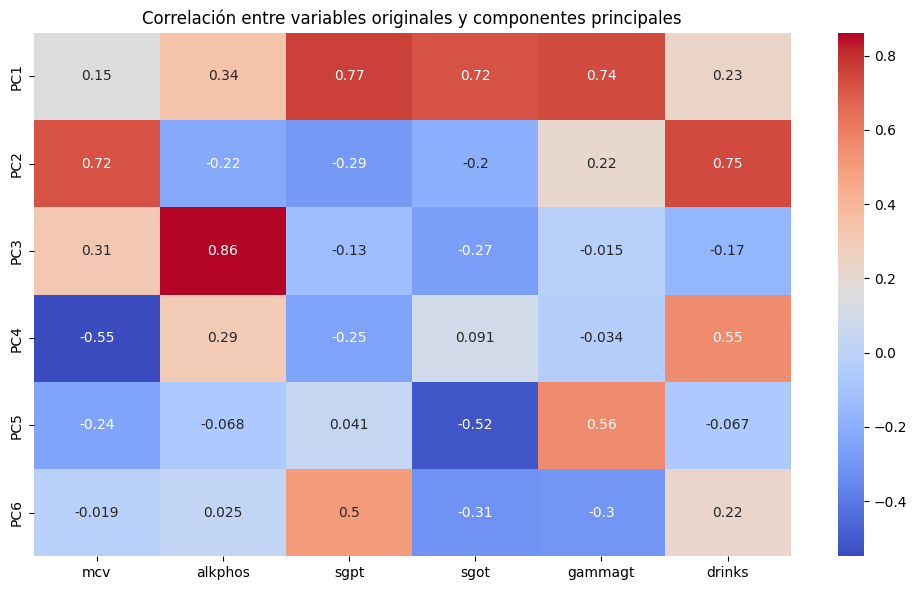

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#es lo que vamos a hacer ahora:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#normalizar las variables numericas
numeric_cols = xy_df.select_dtypes(include=np.number).columns
scaler = StandardScaler()
xy_scaled = xy_df.copy()
xy_scaled[numeric_cols] = scaler.fit_transform(xy_df[numeric_cols]) #se cogen solo las variables numericas

#aplicar pca (analisis componentes principales: en vez de tener muchas variables, se combinan las variables existentes en una: PC1)
pca = PCA()
pca_result = pca.fit_transform(xy_scaled[numeric_cols]) #un PCA para todas las columnas

#crear dataframe con componentes principales
pca_df = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(pca_result.shape[1])])

#mostrar varianza explicada
print("Varianza explicada por cada componente principal")
for i, var in enumerate(pca.explained_variance_ratio_):
  print(f"PC{i+1}: {var: .4f}")

#graficar los dos primeros componentes
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.7)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Visualizacion de los dos primeros componentes principales")
plt.grid(True)
plt.tight_layout()
plt.show()

#correlacion entre variables originales y principales
correlation_matrix = pd.DataFrame(
    np.corrcoef(xy_scaled[numeric_cols].T, pca_df.T)[len(numeric_cols):, :len(numeric_cols)],
    index=[f"PC{i+1}" for i in range(pca_df.shape[1])],
    columns=numeric_cols
)

# Heatmap de correlación
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlación entre variables originales y componentes principales")
plt.tight_layout()
plt.show()

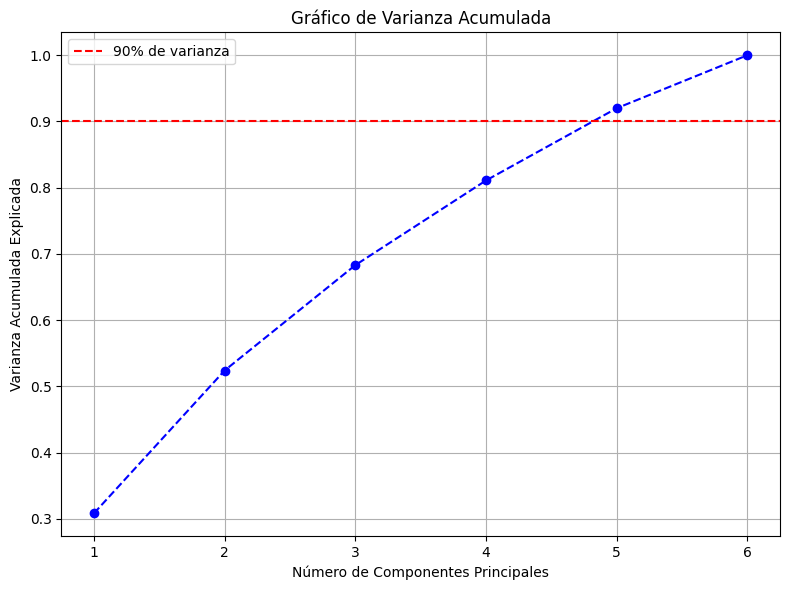

In [ ]:
# Graficar varianza acumulada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('Gráfico de Varianza Acumulada')
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% de varianza')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Importar librerias necesarias
from sklearn.decomposition import PCA

#aplicar PCA sobre las variables numericas normalizadas
pca = PCA(n_components=4) #seleccionamos solo los primeros 4 componentes
pca_results_4 = pca.fit_transform(xy_scaled[numeric_cols])

#crear nuevo DataFrame con los 4 componentes principales
pca_4_df = pd.DataFrame(pca_results_4, columns=[f"PC{i+1}" for i in range(4)])

#mostrar los 4 componentes principales del dataset reducido
print("Dataset reducido con 4 componentes principales")
print(pca_4_df.head())

#opcional: añadir la variable objetivo si quieres usarlo para clasificacion
if 'selector' in xy_df.columns:
  pca_4_df['selector'] = xy_df['selector'].values[:len(pca_4_df)]

Dataset reducido con 4 componentes principales
        PC1       PC2       PC3       PC4
0  2.191951 -2.505325  0.517054 -0.033227
1  0.600252 -0.870075 -0.696029 -0.859889
2  1.304218 -0.899078  0.567880 -0.971997
3 -0.940063 -1.279705 -0.027969  0.367250
4 -1.681929  1.077392  0.607668 -1.937638


In [ ]:
# Importar librerías necesarias
from sklearn.decomposition import PCA

# Aplicar PCA sobre las variables numéricas normalizadas
pca = PCA(n_components=5)  # Seleccionamos solo los primeros 5 componentes
pca_result_5 = pca.fit_transform(xy_scaled[numeric_cols])

# Crear nuevo DataFrame con los 5 componentes principales
pca_5_df = pd.DataFrame(pca_result_5, columns=[f"PC{i+1}" for i in range(5)])

# Mostrar las primeras filas del nuevo dataset reducido
print("✅ Dataset reducido con 5 componentes principales:")
print(pca_5_df.head())

# Opcional: añadir la variable objetivo si quieres usarlo para clasificación
if 'selector' in xy_df.columns:
    pca_5_df['selector'] = xy_df['selector'].values[:len(pca_5_df)]

✅ Dataset reducido con 5 componentes principales:
        PC1       PC2       PC3       PC4       PC5
0  2.191951 -2.505325  0.517054 -0.033227  0.053263
1  0.600252 -0.870075 -0.696029 -0.859889  2.605855
2  1.304218 -0.899078  0.567880 -0.971997  0.228090
3 -0.940063 -1.279705 -0.027969  0.367250 -1.333735
4 -1.681929  1.077392  0.607668 -1.937638 -0.365712


In [ ]:
# 📦 Importar librerías necesarias
import plotly.express as px

# 📈 Visualización 3D de los tres primeros componentes principales
fig = px.scatter_3d(
    pca_5_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='selector' if 'selector' in pca_5_df.columns else None,
    title="Visualización 3D de los Componentes Principales: PC1, PC2 y PC3",
    labels={"PC1": "Componente Principal 1", "PC2": "Componente Principal 2", "PC3": "Componente Principal 3"}
)
fig.show()

In [ ]:
# Dataset completo con la variable objetivo unida
df = X.copy()
df["drinks"] = y

# Personas que NO beben
no_drink = df[df["drinks"] == 0]

# Personas que sí beben
yes_drink = df[df["drinks"] > 0]
#tengo que volver a hacer el análisis de componentes principales ya que los otros contienen drinks
xy_scaled.select_dtypes

<bound method DataFrame.select_dtypes of           mcv   alkphos      sgpt      sgot   gammagt    drinks
0   -1.206442  1.503139  2.352969  1.088553  0.428294 -1.137175
2   -0.956441 -0.807186  0.969486 -1.058972  2.053670 -1.137175
3    0.293561  0.651967  1.084776  0.502864  0.781637 -1.137175
4   -0.706441  0.165583 -1.451609  1.283782 -1.055745 -1.137175
5    2.043564 -0.746388 -1.336318 -0.863743 -0.561065 -1.137175
..        ...       ...       ...       ...       ...       ...
326  0.793562  0.165583  2.468259  1.674241  0.569631  2.259874
327 -0.706441 -0.746388  1.315357 -0.473284  0.004283  2.259874
329 -1.956443 -0.746388 -0.759867  0.307634  1.346985  2.259874
331  1.793564  0.773563 -0.875158 -0.278054  1.983001  2.259874
332  2.543565  0.955957  0.047164  0.502864  0.216288  2.259874

[264 rows x 6 columns]>

In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Normalizar las variables numéricas
num_colums = Xy_df.select_dtypes(include=np.number).columns
numeric_cols = num_colums.drop('drinks')
scaler = StandardScaler()
Xy_scaled = Xy_df.copy()
Xy_scaled[numeric_cols] = scaler.fit_transform(Xy_scaled[numeric_cols])

# Aplicar PCA
pca = PCA()
pca_result = pca.fit_transform(Xy_scaled[numeric_cols])

# Crear DataFrame con componentes principales
pca_df = pd.DataFrame(pca_result, columns=[f"PC{i+1}" for i in range(pca_result.shape[1])])

# Mostrar varianza explicada
print("🔢 Varianza explicada por cada componente principal:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")

# Graficar los dos primeros componentes
plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.7)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Visualización de los dos primeros componentes principales (sin 'drinks')")
plt.grid(True)
plt.tight_layout()
plt.show()

# Correlación entre variables originales y componentes principales
correlation_matrix = pd.DataFrame(
    np.corrcoef(Xy_scaled[numeric_cols].T, pca_df.T)[len(numeric_cols):, :len(numeric_cols)],
    index=[f"PC{i+1}" for i in range(pca_df.shape[1])],
    columns=numeric_cols
)

# Heatmap de correlación
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlación entre variables originales y componentes principales (sin 'drinks')")
plt.tight_layout()
plt.show()

NameError: name 'Xy_df' is not defined

In [ ]:
# Importar librerías necesarias
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Asegurar que 'drinks' esté en el DataFrame de PCA
if 'drinks' not in pca_5_df.columns and 'drinks' in Xy_df.columns:
    pca_5_df['drinks'] = Xy_df['drinks'].values[:len(pca_5_df)]

# Seleccionar variables explicativas y objetivo
X = pca_5_df[['PC1', 'PC2', 'PC3','PC4']]
y = pca_5_df['drinks']

# Crear y entrenar el modelo
model = LinearRegression()
model.fit(X, y)

# Predicciones
y_pred = model.predict(X)

# Evaluación del modelo
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Mostrar resultados
print("Resultados del modelo de regresión lineal:")
print(f"Coeficientes: {model.coef_}")
print(f"Intercepto: {model.intercept_}")
print(f"Error cuadrático medio (MSE): {mse:.4f}")
print(f"Coeficiente de determinación (R²): {r2:.4f}")

In [ ]:
# 📦 Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ✅ Asegurar que 'drinks' esté en el DataFrame de PCA
if 'drinks' not in pca_5_df.columns and 'drinks' in Xy_df.columns:
    pca_5_df['drinks'] = Xy_df['drinks'].values[:len(pca_5_df)]

# 📊 Variables explicativas y objetivo
X = pca_5_df[['PC1', 'PC2', 'PC3', 'PC4']]
y = pca_5_df['drinks']

# 🧠 Modelo de regresión
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)



# 📈 Ajuste lineal entre valores reales y predichos (OLS)
ols_model = LinearRegression()
ols_model.fit(y.values.reshape(-1, 1), y_pred)
line_x = np.linspace(min(y), max(y), 100)
line_y = ols_model.predict(line_x.reshape(-1, 1))



# 📉 Crear gráfico de dispersión con matplotlib
plt.figure(figsize=(8,6))
plt.scatter(y, y_pred, alpha=0.7, edgecolors='k')
plt.title('Relación entre valores reales y predichos de drinks')
plt.plot(line_x, line_y, color='red', linestyle='--', label='Línea de tendencia (OLS)')
plt.xlabel('Valor real de drinks')
plt.ylabel('Valor predicho por el modelo')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# 📋 Mostrar ecuación de la línea de tendencia
print("📊 Ecuación de la línea de tendencia (OLS):")
print(f"y_pred = {ols_model.coef_[0]:.4f} * y_real + {ols_model.intercept_:.4f}")